# **1**. 데이터 불러오기

In [123]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
import pandas as pd

In [125]:
train_data = pd.read_csv('sample_data/california_housing_train.csv', engine='python')
test_data = pd.read_csv('sample_data/california_housing_test.csv', engine='python')

In [126]:
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [127]:
train_x, train_y = train_data.iloc[:, :-1].values, train_data.iloc[:, -1].values
test_x, test_y = test_data.iloc[:, :-1].values, test_data.iloc[:, -1].values

# 2. 데이터 전처리

In [159]:
from sklearn.preprocessing import MinMaxScaler

In [160]:
inp_scaler = MinMaxScaler()
inp_scaler.fit(train_x)
scaled_train_x = inp_scaler.transform(train_x)
scaled_test_x = inp_scaler.transform(test_x)

tar_scaler = MinMaxScaler()
tar_scaler.fit(train_y.reshape(-1, 1))
scaled_train_y = tar_scaler.transform(train_y.reshape(-1, 1))
scaled_test_y = tar_scaler.transform(test_y.reshape(-1, 1))

In [161]:
train_x, train_y = scaled_train_x[:-3000], scaled_train_y[:-3000]
val_x, val_y = scaled_train_x[-3000:], scaled_train_y[-3000:]
test_x, test_y = scaled_test_x, scaled_test_y

In [162]:
print("Train data set:", train_x.shape, train_y.shape)
print("Validation data set:", val_x.shape, val_y.shape)
print("Test data set:", test_x.shape, test_y.shape)


Train data set: (11000, 8) (11000, 1)
Validation data set: (3000, 8) (3000, 1)
Test data set: (3000, 8) (3000, 1)


# 3. Custom Dataset 만들기

In [163]:
import torch
from torch.utils.data import Dataset

In [164]:
class TensorData(Dataset):
  def __init__(self, x, y):
    self.x = torch.Tensor(x)
    self.y = torch.Tensor(y)
    self.len = len(self.y)

  def __getitem__(self, index):
    return self.x[index], self.y[index]

  def __len__(self):
    return self.len

# 4. Dataloader 만들기

In [165]:
from torch.utils.data import DataLoader

In [166]:
train_dataset = TensorData(train_x, train_y)
val_dataset = TensorData(val_x, val_y)
test_dataset = TensorData(test_x, test_y)

In [167]:
print(type(train_dataset))
print(train_dataset[0])

<class '__main__.TensorData'>
(tensor([1.0000, 0.1770, 0.2745, 0.1479, 0.1988, 0.0284, 0.0773, 0.0685]), tensor([0.1070]))


In [168]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [169]:
## 첫 번째 batch 확인

for batch in train_loader:
  print(batch)
  break

## or

batch = next(iter(train_loader))
print(batch[0].shape)
print(batch[1].shape)


[tensor([[0.5912, 0.1642, 0.4510, 0.0268, 0.0349, 0.0158, 0.0304, 0.0757],
        [0.5304, 0.1599, 0.6667, 0.0395, 0.0445, 0.0311, 0.0437, 0.2297],
        [0.4955, 0.1620, 0.5294, 0.0485, 0.1253, 0.0896, 0.1192, 0.0781],
        [0.2665, 0.6824, 0.2941, 0.0819, 0.0885, 0.0247, 0.0546, 0.2069],
        [0.1785, 0.7704, 0.2745, 0.0991, 0.1214, 0.0200, 0.0569, 0.1174],
        [0.5925, 0.1513, 0.6471, 0.0412, 0.0456, 0.0319, 0.0536, 0.2205],
        [0.6080, 0.0740, 0.1961, 0.0985, 0.1172, 0.0619, 0.1192, 0.1797],
        [0.2859, 0.4528, 0.2745, 0.0867, 0.1195, 0.0486, 0.1039, 0.1018],
        [0.4916, 0.1631, 0.1373, 0.0317, 0.0854, 0.0300, 0.0847, 0.0361],
        [0.4851, 0.1631, 0.1569, 0.0409, 0.1262, 0.0477, 0.1248, 0.1047],
        [0.4386, 0.1760, 0.5098, 0.0472, 0.0523, 0.0284, 0.0533, 0.3052],
        [0.2807, 0.4710, 0.2353, 0.0376, 0.0321, 0.0196, 0.0334, 0.2664],
        [0.5252, 0.1706, 0.5490, 0.0556, 0.0711, 0.0529, 0.0734, 0.2194],
        [0.2768, 0.5311, 0.2353, 0.05

# 5. 모델 만들기

In [170]:
import torch.nn as nn

In [171]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()

    self.fc1 = nn.Sequential(nn.Linear(in_features=8, out_features=64),
                             nn.ReLU(),
                             nn.Dropout(0.2))

    self.fc2 = nn.Sequential(nn.Linear(in_features=64, out_features=64),
                             nn.ReLU(),
                             nn.Dropout(0.2))

    self.outputs = nn.Linear(64, 1)

  def forward(self, x):
    x = self.fc1(x)
    x = self.fc2(x)
    x = self.outputs(x)
    return x

# 6. gpu 사용하여 모델 훈련하기

In [172]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [173]:
print(torch.cuda.get_device_name())
print(torch.cuda.device_count())

Tesla T4
1


In [174]:
from torch import optim
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [175]:
train_loss_list = []
val_loss_list = []
n = len(train_loader)
val_n = len(val_loader)
epochs = 50

for epoch in range(epochs):
  train_loss = 0
  model.train()
  for i, data in enumerate(train_loader):
    inputs, targets = data
    inputs, targets = inputs.to(device), targets.to(device)
    optimizer.zero_grad()

    outputs = model(inputs).to(device)
    loss = criterion(outputs, targets)
    train_loss += loss.item()
    loss.backward()
    optimizer.step()


  model.eval()
  val_loss = 0
  with torch.no_grad():
    for x, y in val_loader:
      x, y = x.to(device), y.to(device)
      val_loss += criterion(model(x), y).item()


  train_loss_list.append(train_loss/n)
  val_loss_list.append(val_loss/val_n)
  print(f"Loss  {epoch+1}/{epochs}: Train: {train_loss/n:.4f} \t Val: {val_loss/val_n:.4f}")

Loss  1/50: Train: 0.0431 	 Val: 0.0156
Loss  2/50: Train: 0.0258 	 Val: 0.0218
Loss  3/50: Train: 0.0236 	 Val: 0.0256
Loss  4/50: Train: 0.0220 	 Val: 0.0387
Loss  5/50: Train: 0.0209 	 Val: 0.0372
Loss  6/50: Train: 0.0203 	 Val: 0.0455
Loss  7/50: Train: 0.0193 	 Val: 0.0413
Loss  8/50: Train: 0.0188 	 Val: 0.0415
Loss  9/50: Train: 0.0185 	 Val: 0.0365
Loss  10/50: Train: 0.0181 	 Val: 0.0372
Loss  11/50: Train: 0.0177 	 Val: 0.0350
Loss  12/50: Train: 0.0176 	 Val: 0.0353
Loss  13/50: Train: 0.0172 	 Val: 0.0309
Loss  14/50: Train: 0.0168 	 Val: 0.0337
Loss  15/50: Train: 0.0167 	 Val: 0.0322
Loss  16/50: Train: 0.0165 	 Val: 0.0320
Loss  17/50: Train: 0.0164 	 Val: 0.0354
Loss  18/50: Train: 0.0162 	 Val: 0.0297
Loss  19/50: Train: 0.0162 	 Val: 0.0299
Loss  20/50: Train: 0.0160 	 Val: 0.0285
Loss  21/50: Train: 0.0160 	 Val: 0.0281
Loss  22/50: Train: 0.0157 	 Val: 0.0261
Loss  23/50: Train: 0.0156 	 Val: 0.0289
Loss  24/50: Train: 0.0154 	 Val: 0.0270
Loss  25/50: Train: 0.015

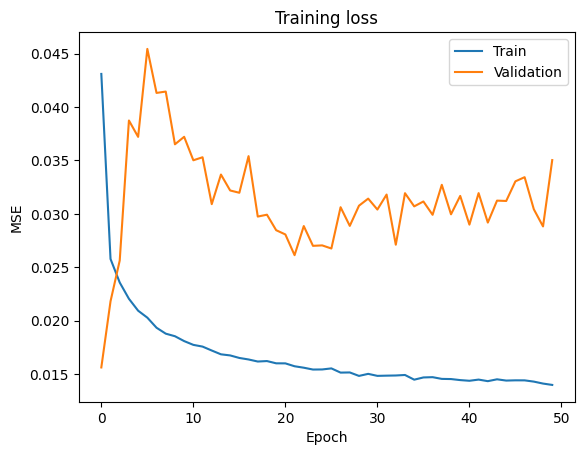

In [176]:
from matplotlib import pyplot as plt
plt.title('Training loss')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.plot(range(epochs), train_loss_list, label='Train')
plt.plot(range(epochs), val_loss_list, label='Validation')
plt.legend()

In [177]:
def relative_error(y, pred):
  return (abs(y-pred))/y

In [178]:
size = len(test_loader)
test_loss = 0
pred_list = []
y_list = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        pred_descaled = torch.tensor(tar_scaler.inverse_transform(pred.cpu()))
        y_descaled = torch.tensor(tar_scaler.inverse_transform(y.reshape(-1, 1).cpu()))
        pred_list.append(pred_descaled[0])
        y_list.append(y_descaled[0])
        test_loss += relative_error(pred_descaled, y_descaled)

test_loss = test_loss/size
print(f"Test Error: \n RMSE: {test_loss} \n")

Test Error: 
 RMSE: tensor([[0.4100]], dtype=torch.float64) 



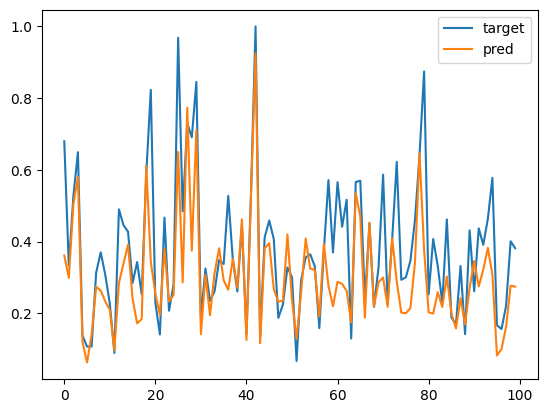

In [179]:
plt.plot(y_list[:100], label='target')
plt.plot(pred_list[:100], label='pred')
plt.legend()
plt.show()